<a href="https://colab.research.google.com/github/kovexison/Practica-AI/blob/AI-71-M3.6-Explore-pretrained-model-OR-custom-experiment/DL_CNN_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Introduction to CNNs for Image Classification

Until now, you've learned how to apply machine learning to structured datasets (like predicting prices or classifying data based on features). But how can we teach a machine to recognize images, like telling the difference between a **headlight**, a **bumper**, or a **wheel**?

That’s where **Convolutional Neural Networks (CNNs)** come in. CNNs are the **go-to architecture** in deep learning when it comes to visual understanding.

---

## 🧩 The Challenge with Image Data

Images are not like tabular data. A single color image of size 128×128 has **49,152 features** (128 × 128 × 3), which:
- Makes them **high-dimensional**
- Contains **spatial relationships** (e.g. a tire is round, and a headlight has glassy edges)
- Makes flattening them (as we did in ML) **lose important context**

Traditional ML methods treat all pixels independently. But CNNs understand **space** — they "look" at nearby pixels together, like how our eyes and brains work.

---

## 👁️ What is a CNN?

CNNs (Convolutional Neural Networks) are **neural networks designed specifically for images**. They learn patterns from raw pixel data through **filters** that scan the image.


![How a CNN Works](./images_gifs/cnnimage.png)


### Think of CNNs as layers of virtual eyes:
1. **Early layers** detect **edges**, **lines**, and **color patterns**
2. **Middle layers** detect **shapes**, **textures**, or **symmetry**
3. **Later layers** detect **parts**, **objects**, or **combinations**

All this happens without us manually designing the features. CNNs learn them during training.

---

![Digits](images_gifs/cnndigits.gif)

### 💡 How a CNN Works (Layer Ideas)

**Convolution Layer**
➤ Learns small visual patterns (like edges, curves, textures)
➤ Uses filters that slide over the image

**Activation (ReLU)**
➤ Keeps only useful signals (sets negatives to 0)
➤ Adds non-linearity so it can learn complex patterns

**Pooling Layer**
➤ Shrinks the feature maps (like zooming out)
➤ Keeps the strongest features (e.g., max pooling)

**More Conv + Pool Layers**
➤ Deeper layers learn higher-level parts (like car lights, tires)
➤ Each layer builds on the previous ones

**Flatten Layer**
➤ Turns 2D feature maps into a 1D vector
➤ Prepares data for the final decision

**Fully Connected (Dense) Layers**
➤ Combine all features to predict the class
➤ Similar to layers in traditional neural networks

**Softmax Output**
➤ Outputs class probabilities
➤ The highest value is the model’s prediction

![convs](images_gifs/convolutions.gif)

### Your Challenge:

In this notebook, we’ll train a CNN to recognize different **car parts** from images. These might include parts like:
- air compressor
- battery
- brake caliper
- coil spring
- oil pan and so on

**Total of 50 car parts**


You don’t need to **tell** the model what a headlight looks like — it will **learn** the patterns by itself from labeled training images.


By the end of this notebook, you'll be able to:

✅ Load and preprocess image data  
✅ Build your own CNN using TensorFlow/Keras  
✅ Train and evaluate the model  
✅ Visualize performance with graphs and confusion matrices  
✅ Experiment with changes and improve accuracy  


## 🖼️ Let's Look at Some Examples!

Before we start coding, here are some sample images from our dataset (randomly picked from different classes):

Note: if we are using colab we have to run the following line of code to conect the dataset from Google Drive to the environment

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


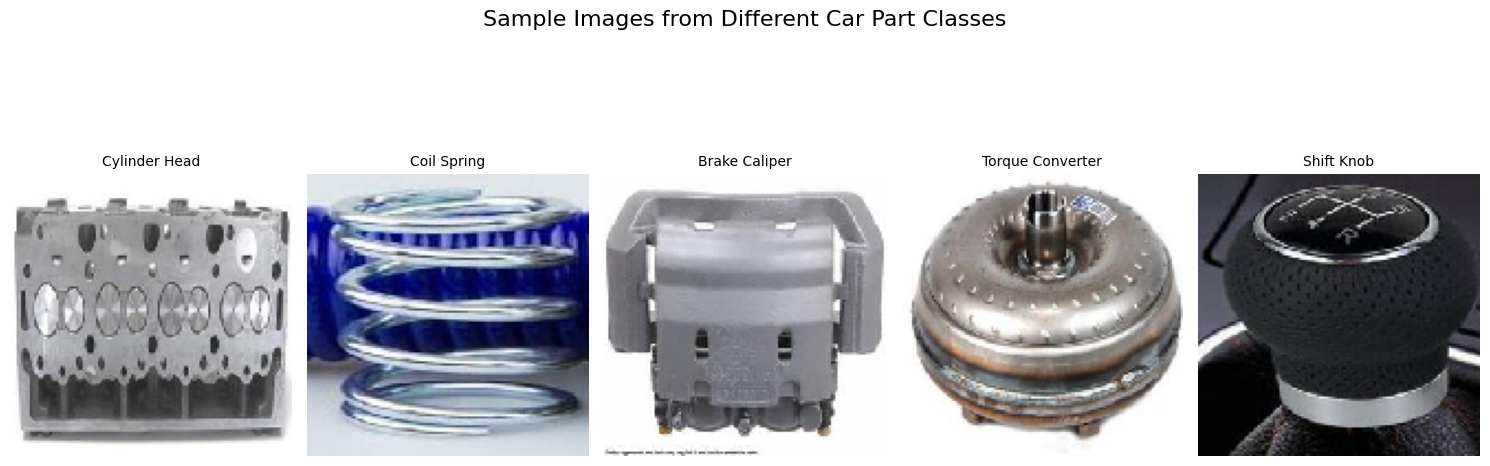

In [24]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image
from PIL import Image

dataset_path = './drive/MyDrive/dataset/train'

class_dirs = [d for d in os.listdir(dataset_path)
              if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')]

sampled_classes = random.sample(class_dirs, min(5, len(class_dirs)))

plt.figure(figsize=(15, 6))

for i, class_name in enumerate(sampled_classes):
    class_folder = os.path.join(dataset_path, class_name)

    valid_extensions = ['.jpg', '.jpeg', '.png']
    images_in_class = [f for f in os.listdir(class_folder)
                       if f.lower().endswith(tuple(valid_extensions)) and not f.startswith('.')]

    if not images_in_class:
        continue

    sample_image = random.choice(images_in_class)
    img_path = os.path.join(class_folder, sample_image)

    img = image.load_img(img_path, target_size=(128, 128))
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name.title(), fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from Different Car Part Classes", fontsize=16)
plt.tight_layout()
plt.show()


In [25]:
import pandas as pd

# Load dataset
df = pd.read_csv('./drive/MyDrive/dataset/car parts.csv')
df.head(20)

,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train
5,0,train/AIR COMPRESSOR/006.jpg,AIR COMPRESSOR,train
6,0,train/AIR COMPRESSOR/007.jpg,AIR COMPRESSOR,train
7,0,train/AIR COMPRESSOR/008.jpg,AIR COMPRESSOR,train
8,0,train/AIR COMPRESSOR/009.jpg,AIR COMPRESSOR,train
9,0,train/AIR COMPRESSOR/010.jpg,AIR COMPRESSOR,train


In [26]:
label_counts = df['labels'].value_counts().sort_values(ascending=False)
label_counts

,count
labels,
IGNITION COIL,210
IDLER ARM,208
STARTER,205
CARBERATOR,202
ALTERNATOR,200
OVERFLOW TANK,199
SHIFT KNOB,199
RADIO,199
FUEL INJECTOR,198


#### TODO: Research about data augmentation and what to do in case of an unbalanced dataset
##### At the end of the notebook, you can apply these techniques and train another CNN and compare results

### Your task:

#### Quick CNN Workflow for Image Classification

1. **Load & preprocess data**  
   - Resize images and normalize pixel values (e.g., scale pixels to [0,1])  
   - Prepare labels for classification  

2. **Create training and validation data generators**  
   - Use `ImageDataGenerator` or custom loaders to batch and augment data  (If you want to, or skip this part for now)

3. **Build the CNN model**  
   - Stack convolutional layers (Conv2D + activation function) and pooling layers
   - Flatten and add dense layers for final classification  
   - Make sure to use the right activation function for the last Dense layer.

4. **Compile the model**  
   - Use suitable loss function nd an optimizer like Adam  

5. **Train the model**  
   - Fit the model on training data and validate on validation data over multiple epochs  
   - Find the right number of batches/epochs for your data

6. **Evaluate and visualize results**  
   - Plot Accuracy & Loss Curves for training/validation
   - Learn about overfitting/underfitting and how to prevent these situations
   - Generate confusion matrix and classification report, based on metrics like accuracy

7. **Explore**
   - Use a pretrained available model
   - Change the architecture
   - Integrate the model into a small GUI and make it more interactive
   - Test with images from the internet, and see how well it performs


# Part 1: Visualize and Process the Data

## Chapter 1: take a look

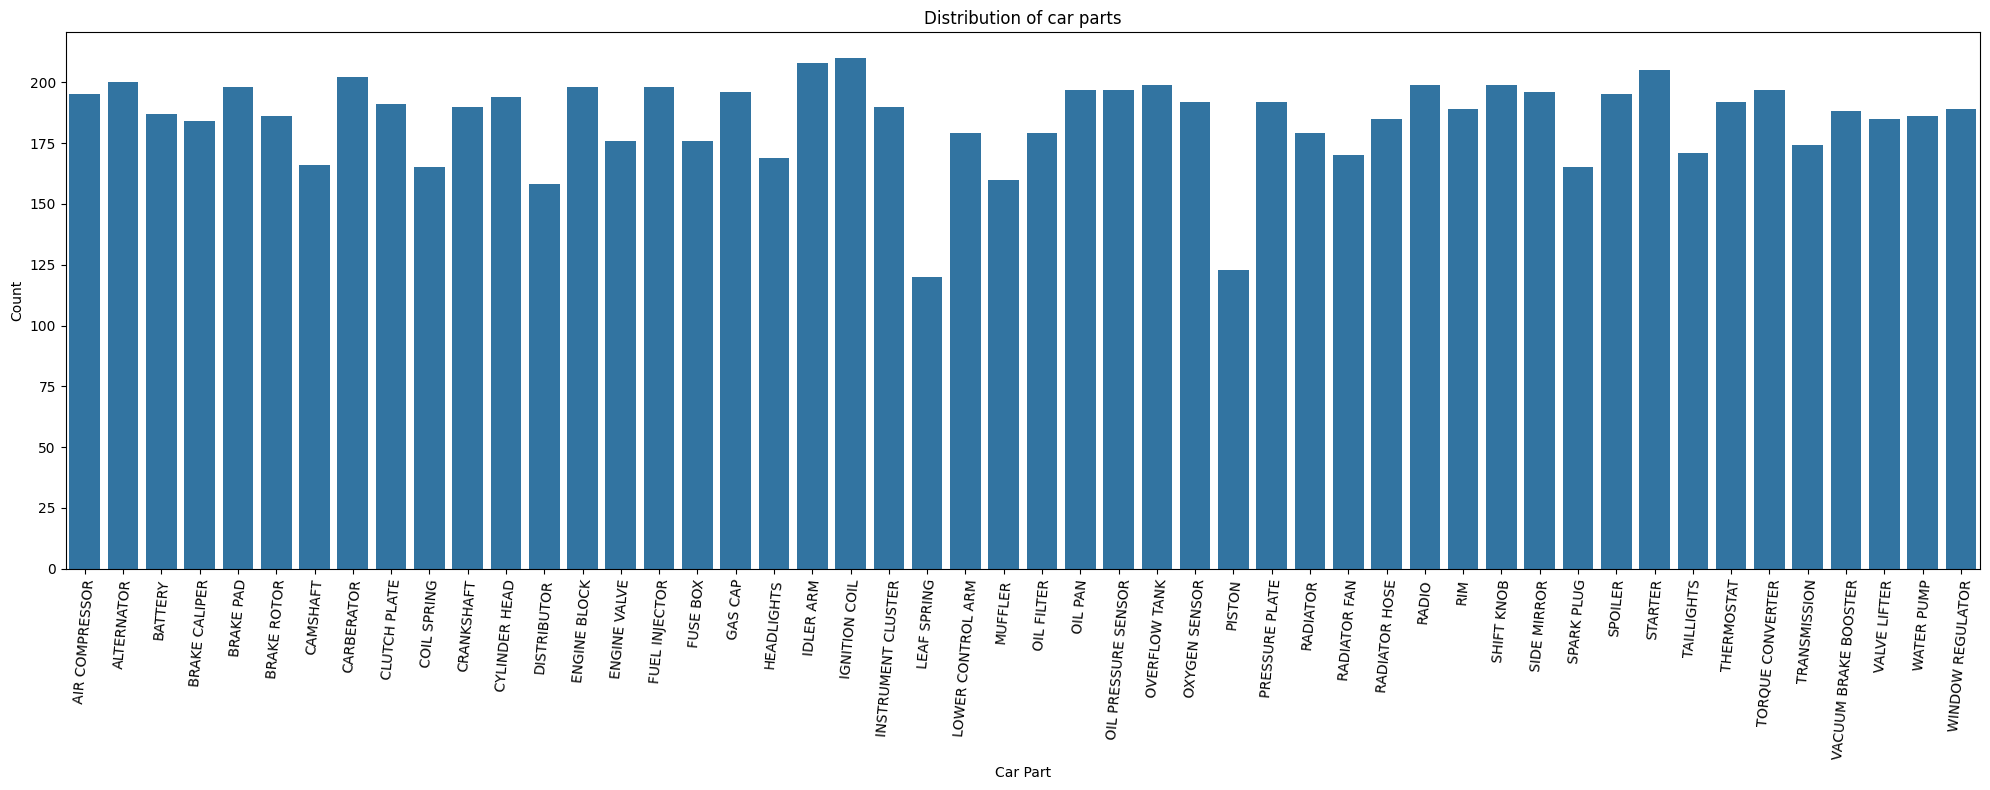

Our set has a total of 9239 examples distributed among 50 car parts and test-train-validation splits; we see that the lowest count is 120, whereas the highest count is 210.
This is a difference of 57.1429% or a ratio of 1.75.


In [5]:
import seaborn as sns

plt.figure(figsize=(20, 8))
sns.countplot(x=df['labels'])
plt.title("Distribution of car parts")
plt.xlabel("Car Part")
plt.ylabel("Count")
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()

print(f"Our set has a total of {df.shape[0]} examples distributed among {len(label_counts)} car parts and test-train-validation splits; we see that the lowest count is {min(label_counts)}, whereas the highest count is {max(label_counts)}.")
print(f"This is a difference of {(min(label_counts)*100/max(label_counts)):.4f}% or a ratio of {max(label_counts) / min(label_counts):.2f}.")

While not ideal, this is not a concern for us right now as this imbalance is considered a mild to moderate imbalance. Problems arise when the smallest class has only a few dozen examples (we have 120) or the ratio is something like 10:1 or above.
If we see that the underrepresented classes have lower scores during training or testing we can address this issue.
However, the real problem might be the fact that we have so many categories and each category represents only a small portion of the dataset. This problem can be addressed by using other techniques like transfer learning or data augmentation to all the classes.

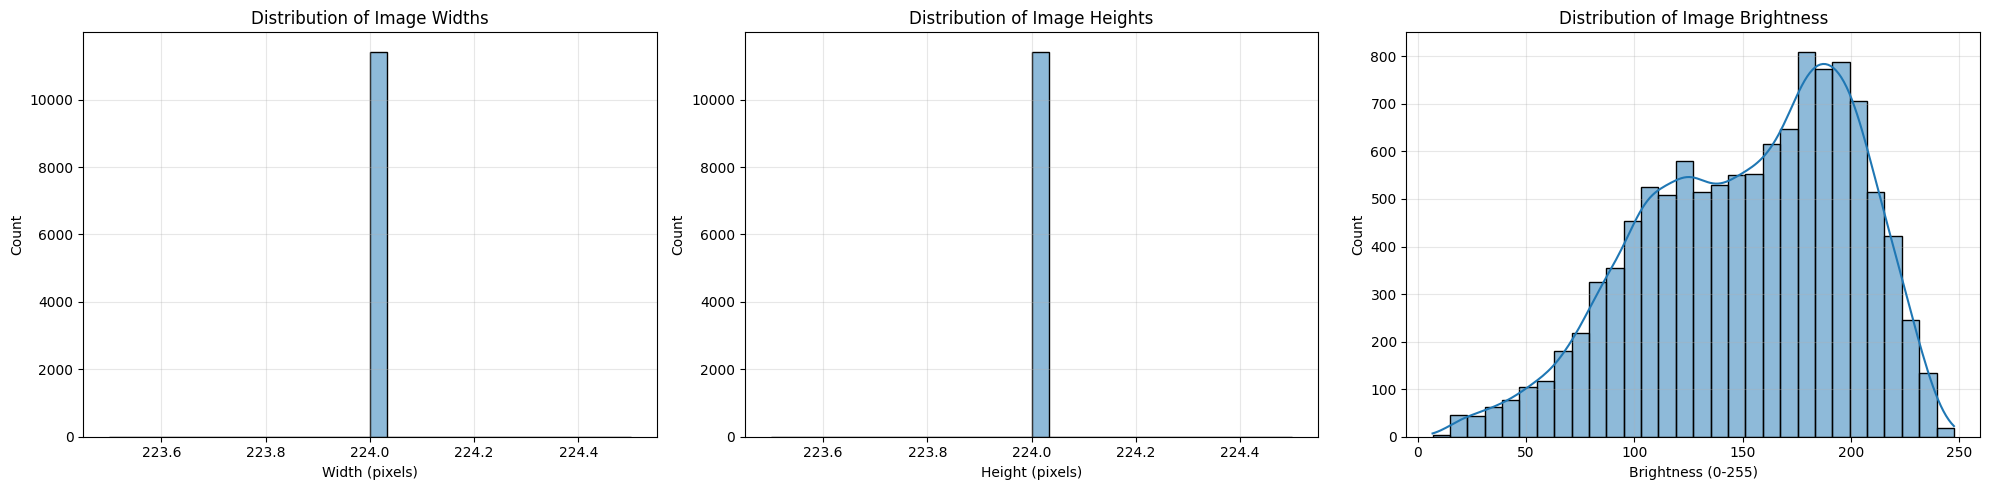

A random image's height: 224 and a random image's width: 224


In [ ]:
# running this cell in Google Colab crashes the session because it uses too much RAM
# read the images and show the distribution of their sizes
from pathlib import Path
import numpy as np
import cv2

dataset = Path('./drive/MyDrive/dataset/train')
widths = []
heights = []
brightness_values = []
image_array = []

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))
for img_path in dataset.rglob("*"):
    if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:

        # width-height measurements
        with Image.open(img_path) as img:
            widths.append(img.width)
            heights.append(img.height)

        # brightness measurements
        img = cv2.imread(str(img_path))
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness_values.append(np.mean(gray))

        # compute average image
        try:
            img = Image.open(str(img_path)).convert("RGB")
            arr = np.asarray(img, dtype=np.float32) / 255.0
            image_array.append(arr)
        except Exception as e:
            print(f"{img_path} is an invalid image.")

sns.histplot(widths, bins=30, kde=True, ax=axs[0])
axs[0].set_title("Distribution of Image Widths")
axs[0].set_xlabel("Width (pixels)")
axs[0].set_ylabel("Count")
axs[0].grid(alpha=0.3)

sns.histplot(heights, bins=30, kde=True, ax=axs[1])
axs[1].set_title("Distribution of Image Heights")
axs[1].set_xlabel("Height (pixels)")
axs[1].set_ylabel("Count")
axs[1].grid(alpha=0.3)

sns.histplot(brightness_values, bins=30, kde=True, ax=axs[2])
axs[2].set_title("Distribution of Image Brightness")
axs[2].set_xlabel("Brightness (0-255)")
axs[2].set_ylabel("Count")
axs[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"A random image's height: {random.choice(heights)} and a random image's width: {random.choice(widths)}")

# display the average image
images = np.stack(image_array, axis=0)
avg_image = images.mean(axis=0)
avg_image_255 = (avg_image * 255).astype(np.uint8)
plt.figure(figsize=(6, 6))
plt.imshow(avg_image_255)
plt.title("Average Image")
plt.axis("off")
plt.show()

The dataset contains images with a uniform resolution of 224x224 pixels and an aspect ratio of 1:1. This is a good starting point as we don't have to implement any pipelines that resize or crop the images,  and the model won't have to deal with noise (different resolutions) when it classifies the images. The situation is good regarding brightness as well; although it varies a bit, there is only one peak at ~200, with most of the images around 100-200 range. There are only a few dark images, which is a good point. This relatively uniform distribution of the brightness suggests that the dataset is consistent and most probably is taken from one source only.
Meanwhile, the average image is... boring? While the idea is interesting, we can't learn too much from it. We see that usually images are in the center, which is good as it is clearer for the model where the subject is. The brightness is also relatively high, as discussed in the brightness histogram

## Chapter 2: build a pipeline

We use pipelines to streamline the process of preprocessing the images, such as standardization and normalization (reduce RGB values to [0, 1]. This ensures that the images are in a consistent format before being fed into the CNN model.

In [27]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "./drive/MyDrive/dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "./drive/MyDrive/dataset/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False # Validation doesn't need shuffle for metrics
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "./drive/MyDrive/dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False # CRITICAL: Must be False for manual classification reports
)

Found 11426 files belonging to 50 classes.
Found 250 files belonging to 50 classes.
Found 250 files belonging to 50 classes.


In [28]:
# Normalize pixel values to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

valid_ds = valid_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

So far we have loaded the dataset into batches and standardized and normalized pixels values, essentially creating a pipeline. Now it's time we test the pipeline and see if it works as expected.

In [29]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

for images, labels in train_ds.take(1):
    print("\nMinimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 50)

Minimum pixel value: 0.0
Maximum pixel value: 1.0


The correct range for pixel values is [0, 1], which is what we see here. Plus, we see that each batch contains 32 images of size 224x224 with 3 color channels (RGB).

In order to prevent some crashes due to the server running out of RAM and speeding up some computations, we are going to enable prefetching and mixed precision. Mixed precision performs calculations in float16 where appropiate.

In [30]:
import tensorflow as tf

# Apply prefetching to the datasets
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [31]:
# Enable mixed precision for compatible GPUs
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')
print(f'Mixed precision policy set to: {mixed_precision.global_policy().name}')

Mixed precision policy set to: mixed_float16


# Part 2: build a simple, baseline CNN model


## Chapter 1: initialize the model

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense)

model = Sequential([
    # Conv Block 1
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Conv Block 2
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Conv Block 3
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(50, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,796,466 (98.41 MB)

 Trainable params: 25,796,466 (98.41 MB)

 Non-trainable params: 0 (0.00 B)

We have created a CNN with 3 convolution layers (each followed by a max pooling layer) and 2 dense layers. As you can see, the model is big with a size of almost 100 MB, most of which are in the first dense layer. This is typical for CNNs, as dense layers connect every neuron to every other neuron and feature from the flattened output of convolutional layers.

## Chapter 2: compile and train the model

Compiling the model involves configuring the model's loss function, optimizer and metrics. It has nothing to do with code compiling like in C.

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # used because we are dealing with categorical data
    metrics=['accuracy'])

In [34]:
# WARNING! it takes 55 minutes to train the model on the laptop

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20)

Epoch 1/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 57s 107ms/step - accuracy: 0.3014 - loss: 3.0022 - val_accuracy: 0.4480 - val_loss: 2.0714
Epoch 2/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.7535 - loss: 0.9305 - val_accuracy: 0.4800 - val_loss: 2.5728
Epoch 3/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.9405 - loss: 0.2153 - val_accuracy: 0.4520 - val_loss: 3.5969
Epoch 4/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.9720 - loss: 0.1022 - val_accuracy: 0.4440 - val_loss: 3.8005
Epoch 5/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.9813 - loss: 0.0709 - val_accuracy: 0.4520 - val_loss: 3.7572
Epoch 6/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9838 - loss: 0.0627 - val_accuracy: 0.4640 - val_loss: 4.2353
Epoch 7/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9845 - loss: 0.0582 - val_accuracy: 0.4360 - val_loss: 4.2980
Epoch 8/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.9891 - loss: 0.0336 -

After a lengthy wait, it is time to plot some graphs and see how well the model performed throughout the training process. Let's start with the loss curves for both training and validation datasets.

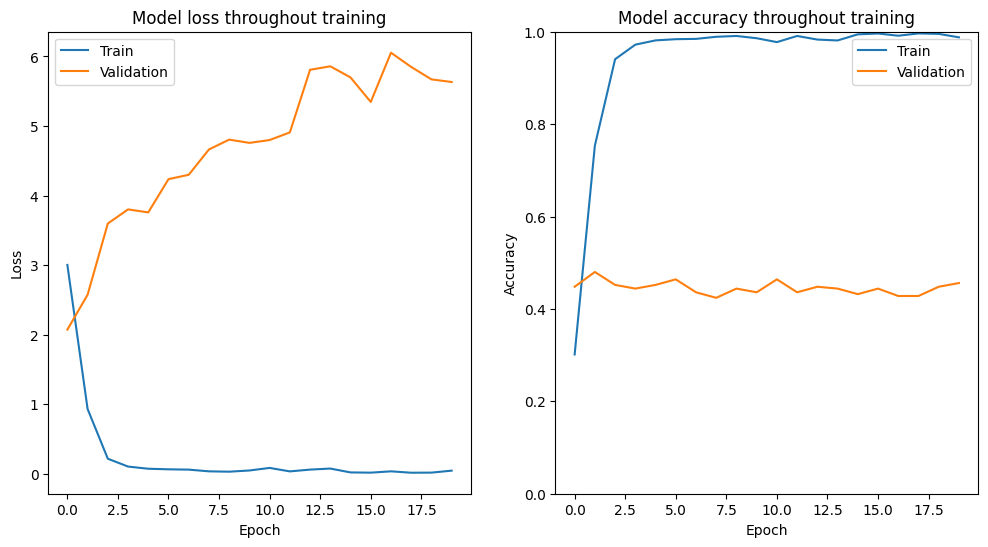

In [35]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axs[0].plot(history.history['loss'])
axs[0].plot(history.history['val_loss'])
axs[0].set_title("Model loss throughout training")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend(['Train', 'Validation'])

axs[1].plot(history.history['accuracy'], animated=True)
axs[1].plot(history.history['val_accuracy'])
axs[1].set_ylim(0, 1)
axs[1].set_title("Model accuracy throughout training")
axs[1].set_title("Model accuracy throughout training")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend(['Train', 'Validation'])

plt.show()

First, let's start with a dumb model for reference: it would have an accuracy of about 2.2% (~1/50) as it would always predict the most common class.
By this observation, we can say that the model is performing well, with a validation accuracy of 40%, a huge improvement over the dumb model. However, a 40% accuracy remains relatively low for a practical classification model. To make matters worse, it seems that the validation accuracy didn't improve throughout the epochs; moreover, the training accuracy approaches 100% after the 7th epoch, a clear sign of overfitting
Looking at the loss curves we see the same story: the training loss approaches 0 while the validation loss, counterintuitively, keeps increasing. This is also another clear sign of overfitting. Funnily, this also suggests that training made our model WORSE at classifying images as it is more confident in its incorrect predictions (a loss of about 7 corresponds to a probability of 0.001 assigned to the correct class)

Now that we have identified the problem, how do we fix it? Let's look at the problems and talk about different solutions:
- after the 6-7th epoch the model appears to have learned the training images and achieves some great test results. Probably there isn't enough variety in the training dataset and the model learns the specific training examples rather than generalizing some features. This can be fixed by artificially increasing the size of the training data through **data augmentation**. This is a technique that applies random transformations to the training images, such as rotations, flips, and color adjustments, to create new variations of the images. This helps the model learn more robust features and reduces overfitting, as the images are a bit more diverse.
- **dropout** is another technique that can be used to reduce overfitting. It randomly disables neurons during training, preventing the network from becoming overly dependent on specific activations. This encourages more robust feature learning and reduces memorization of the training set.
- as seen from the graphs, validation accuracy stops improving after a few epochs, so why keep training? We can use **early stopping** to monitor the validation loss and stop training when it stops improving.
- other techniques include reducing the size of the network and penalizing larger weights (L1/L2 regularization) in order to simplify the model

## Chapter 3: testing the model

After training the model and seeing how it performs during training it is time to see how well it generalizes on an unseen dataset, the test set. Here we will also print a more detailed report.

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
                      precision    recall  f1-score   support

      AIR COMPRESSOR       0.33      0.20      0.25         5
          ALTERNATOR       0.40      0.40      0.40         5
             BATTERY       0.43      0.60      0.50         5
       BRAKE CALIPER       0.21      0.80      0.33         5
           BRAKE PAD       0.00      0.00      0.00         5
         BRAKE ROTOR       0.50      0.20      0.29         5
            CAMSHAFT       0.40      0.40      0.40         5
          CARBERATOR       0.57      0.80      0.67         5
        CLUTCH PLATE       1.00      0.60      0.75         5
         COIL SPRING       0.80      0.80      0.80         5
          CRANKSHAFT       0.67      0.80      0.73         5
       CYLINDER HEAD       0.33      0.20      0.25         5
         DISTRIBUTOR       0.50      0.20      0.29         5
        ENGINE BLOCK       0.50      0.60      0.55         5
        ENGINE VALVE       1.00

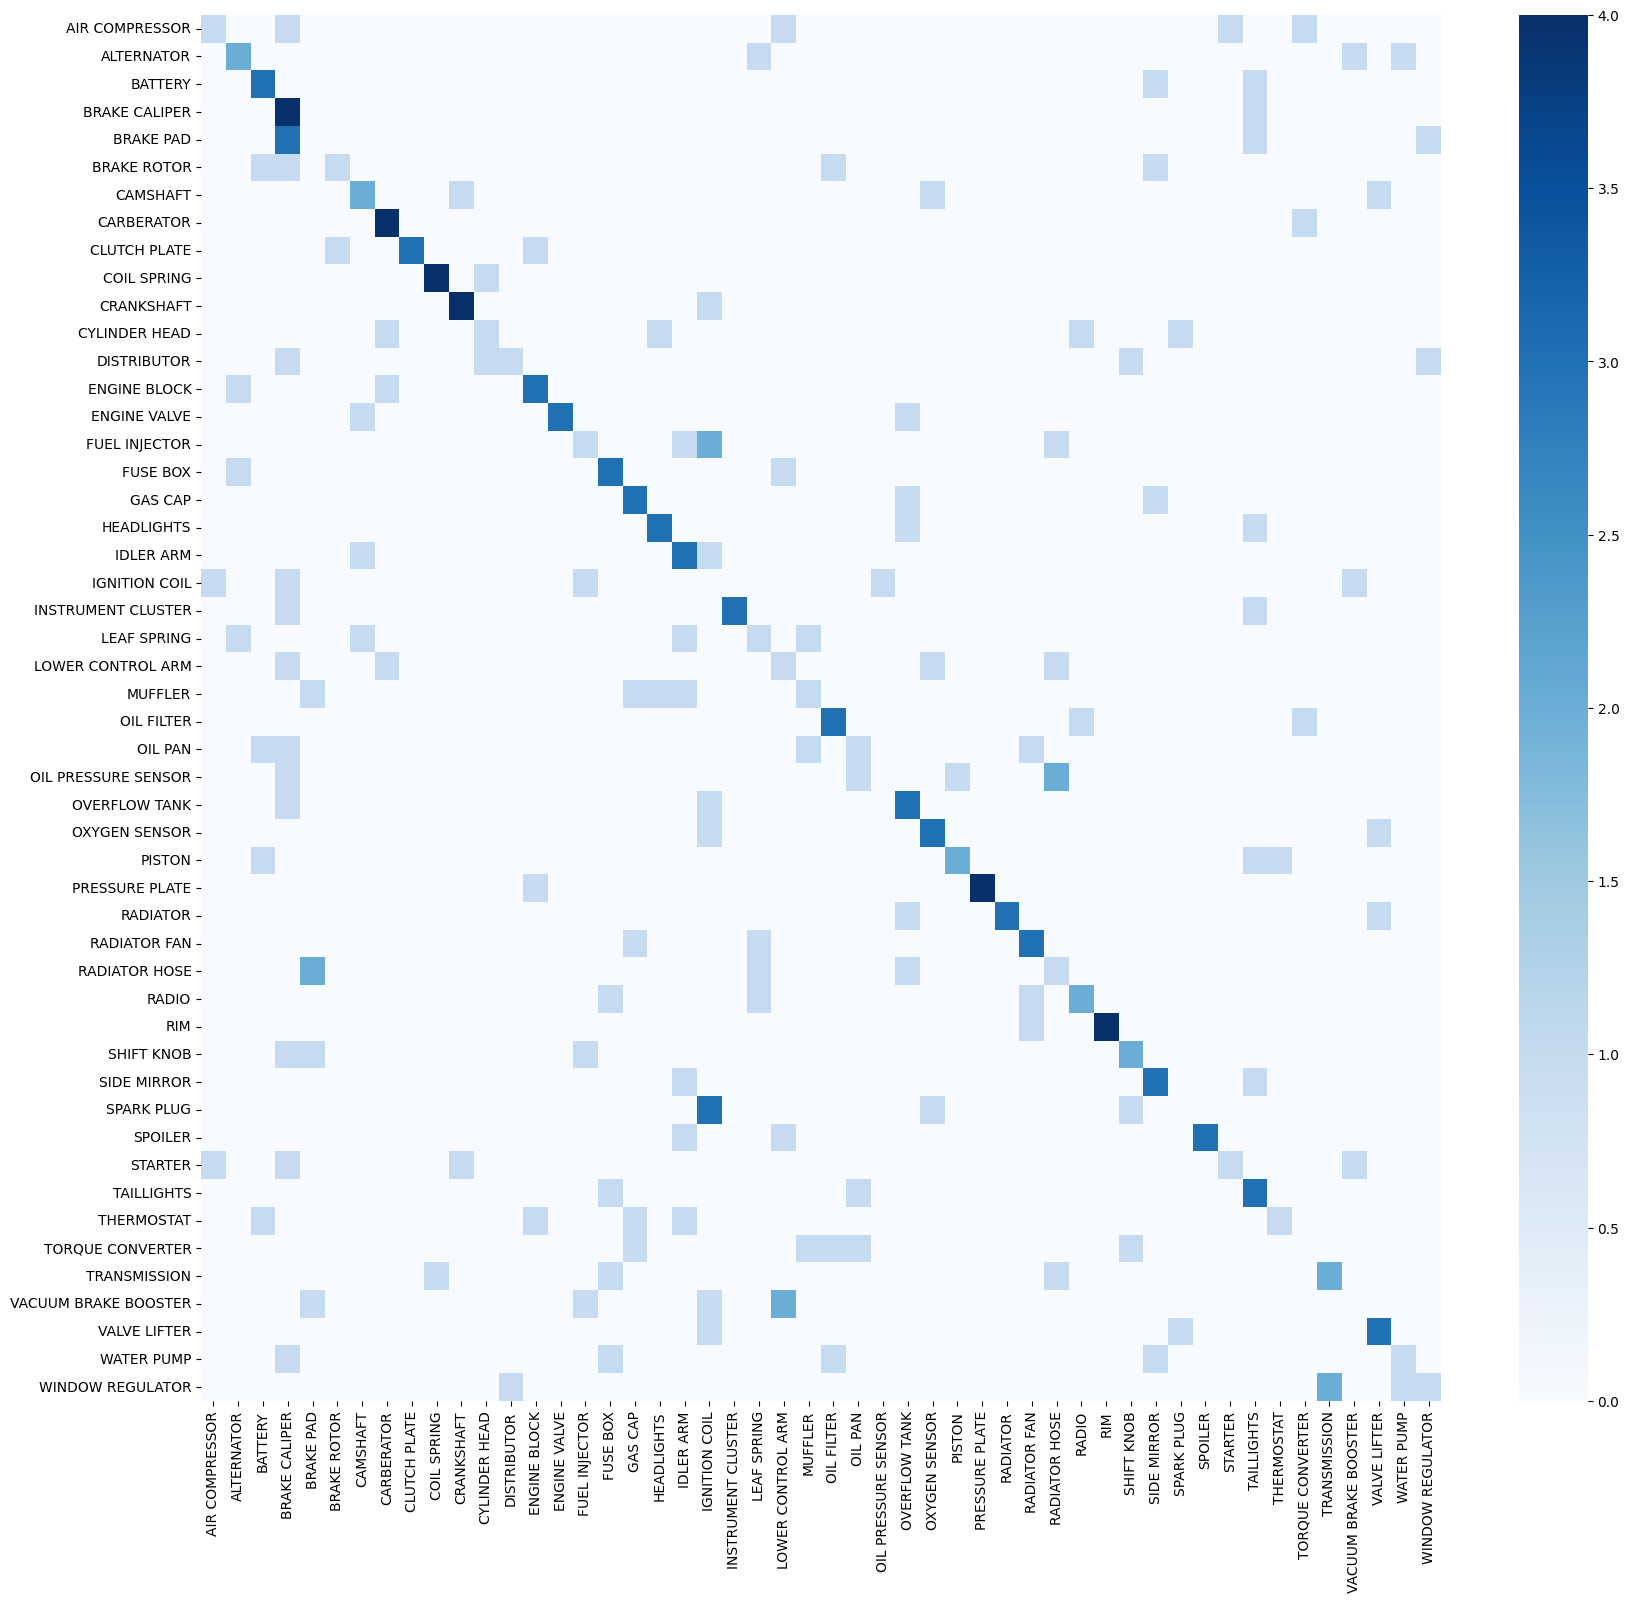

In [36]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Now that shuffle=False, predictions and true labels will align
y_pred_logits = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred_logits, axis=1)

# Get true labels in a stable order
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds], axis=0)

# Get class names
train_data_path = "./drive/MyDrive/dataset/train"
class_names = sorted([d.name for d in os.scandir(train_data_path) if d.is_dir()])

# classification Report
print(classification_report(y_true, y_pred_classes, target_names=class_names, zero_division=0))

# confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.show()

As expected, the model generalizes like it did during training, with 40% accuracy. The confusion matrix looks ok, you can see the diagonal line, but it clearly isn't perfect, as 40% is a bit low for a classification task.

In [37]:
print(f"Shape of y_true: {y_true.shape}")
print(f"Data type of y_true: {y_true.dtype}")
print(f"First 10 values of y_true: {y_true[:10]}\n")

print(f"Shape of y_pred_classes: {y_pred_classes.shape}")
print(f"Data type of y_pred_classes: {y_pred_classes.dtype}")
print(f"First 10 values of y_pred_classes: {y_pred_classes[:10]}\n")

print("Each value in both arrays represents the class index (an integer) for a given image.")
print("y_true contains the actual class labels, while y_pred_classes contains the model's predicted class labels.")
print("The order of images in y_true and y_pred_classes corresponds to the order they were processed from the test_ds.")

Shape of y_true: (250,)
Data type of y_true: int64
First 10 values of y_true: [0 0 0 0 0 1 1 1 1 1]

Shape of y_pred_classes: (250,)
Data type of y_pred_classes: int64
First 10 values of y_pred_classes: [ 0 44 41 23  3  1 22 48 46  1]

Each value in both arrays represents the class index (an integer) for a given image.
y_true contains the actual class labels, while y_pred_classes contains the model's predicted class labels.
The order of images in y_true and y_pred_classes corresponds to the order they were processed from the test_ds.


In [38]:
# find the most confused classes
from collections import Counter, deque

def most_frequent(lst):
  return Counter(lst).most_common(1)[0]

# map all the predictions to their classes
predictions = {}
for cls in y_true:
  predictions[cls] = []

for i in range(len(y_pred_classes)):
  if y_true[i] != y_pred_classes[i]:
    predictions[y_true[i]].append(y_pred_classes[i])

# find the most confused classes
most_confused = deque(maxlen=3)
max_count = -1
for cls, preds in predictions.items():
  biggest_count = most_frequent(preds) # the maximum number of times a class was confused

  if biggest_count[1] == max_count:
    if len(most_confused) == 3:
      most_confused.popleft()
    most_confused.append((cls, biggest_count)) # add to the queue: the class and which class it was mostly categorized as and the count
  elif biggest_count[1] > max_count:
    if len(most_confused) == 3:
      most_confused.popleft()
    most_confused.append((cls, biggest_count))
    max_count = biggest_count[1]

# print stats for each class
for i in range(3):
  str = f"most confused value is class {most_confused[i][0]} ({class_names[most_confused[i][0]]}) which was confused {most_confused[i][1][1]} times with class {most_confused[i][1][0]} ({class_names[most_confused[i][1][0]]})."
  if i == 0:
    str = "first " + str
  elif i==1:
    str = "second " + str
  elif i==2:
    str = "third " + str
  str = "The " + str
  print(str)


The first most confused value is class 3 (BRAKE CALIPER) which was confused 1 times with class 42 (TAILLIGHTS).
The second most confused value is class 4 (BRAKE PAD) which was confused 3 times with class 3 (BRAKE CALIPER).
The third most confused value is class 39 (SPARK PLUG) which was confused 3 times with class 20 (IGNITION COIL).


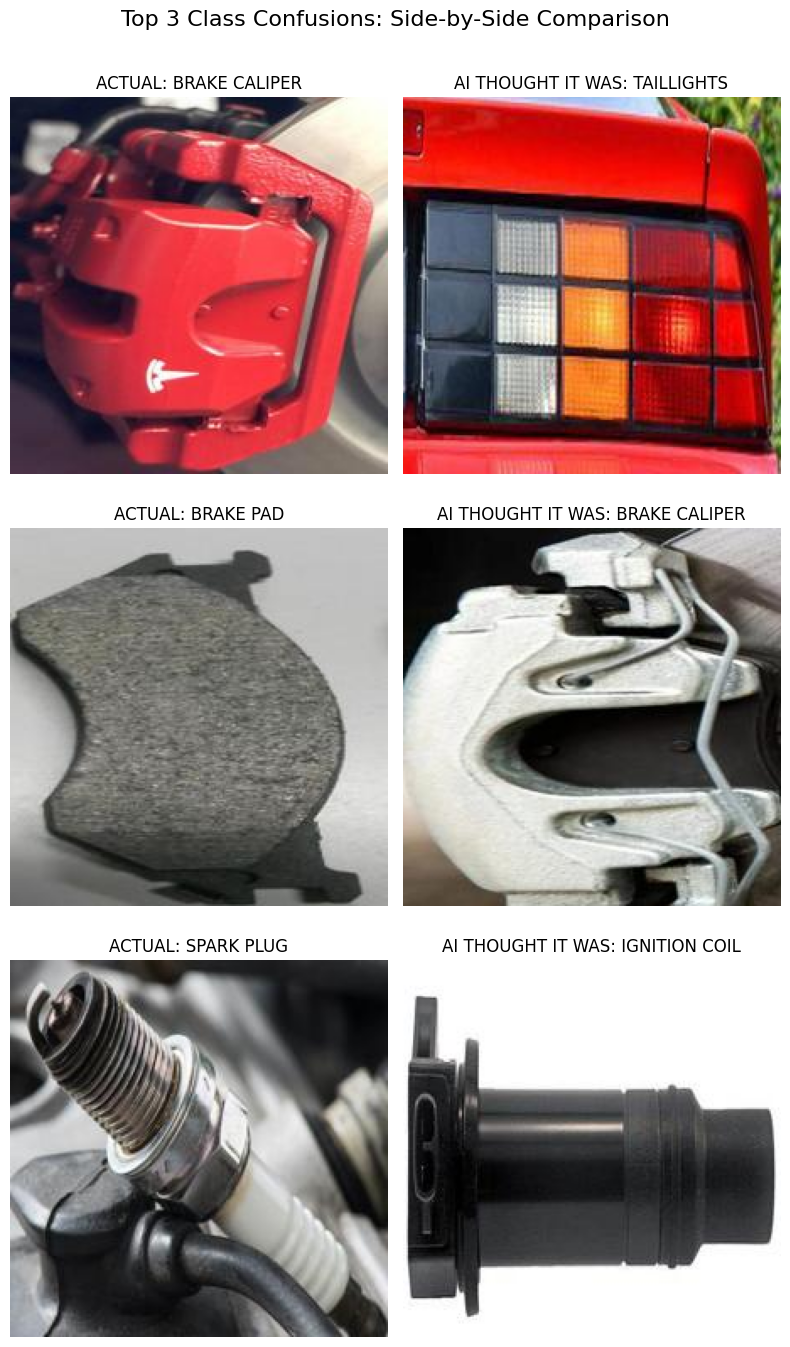

In [39]:
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image

fig, axes = plt.subplots(3, 2, figsize=(8, 15))

for i in range(3):
    true_idx = most_confused[i][0]
    pred_idx = most_confused[i][1][0]

    true_name = class_names[true_idx]
    pred_name = class_names[pred_idx]

    # Helper to get a random image path from a class folder
    def get_random_img(c_name):
        folder = os.path.join(dataset_path, c_name)
        exts = ('.jpg', '.jpeg', '.png')
        imgs = [f for f in os.listdir(folder) if f.lower().endswith(exts)]
        return os.path.join(folder, random.choice(imgs))

    # Load images
    img_true = image.load_img(get_random_img(true_name), target_size=(224, 224))
    img_pred = image.load_img(get_random_img(pred_name), target_size=(224, 224))

    # Plot True Class
    axes[i, 0].imshow(img_true)
    axes[i, 0].set_title(f"ACTUAL: {true_name}")
    axes[i, 0].axis('off')

    # Plot Predicted Class
    axes[i, 1].imshow(img_pred)
    axes[i, 1].set_title(f"AI THOUGHT IT WAS: {pred_name}")
    axes[i, 1].axis('off')

plt.suptitle("Top 3 Class Confusions: Side-by-Side Comparison", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

We can see that sometimes images look alike (like in the case of oxygen sensor and spoiler), but others have nothing to do with one another and it may seem weird that the AI grouped them together.

# Part 3: get a better model

## Chapter 1: improve the existing model 🏋️‍♂️
As talked previously, our model is overfitting very badly. In this chapter we are going to try some techniques to solve that, like data augmentation (on training data only) and dropout.
These techniques should encourage the model to learn more general patterns regarding the data, rather than specific features of the training set.

### Data augmentation
This pipeline will be added as the first layer in our improved model. Every epoch, data_augmentation will apply some modifications to the images and the model will see new images; this way, there are as many new images created as we want, by setting the number of epochs. The model is not guaranteed to ever see the original images, because the data_augmentation pipeline runs from the very first epoch up until the last one _only_ during training.

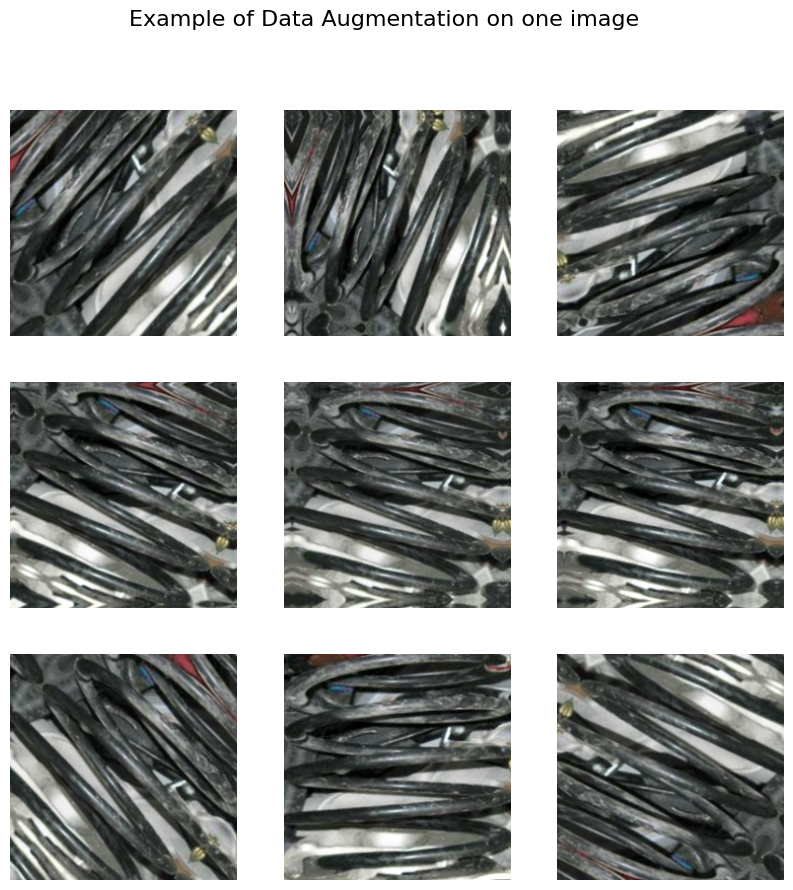

In [41]:
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Define the augmentation pipeline
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1)
])

# Example of how to visualize the augmentation on a single image
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Expand dims to simulate a batch of 1
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))

        # Fix: Convert to float32 because matplotlib doesn't support float16 (from mixed precision)
        # and clip to [0, 1] range
        img_to_show = augmented_image[0].numpy().astype("float32")
        img_to_show = np.clip(img_to_show, 0, 1)

        plt.imshow(img_to_show)
        plt.axis("off")
    plt.suptitle("Example of Data Augmentation on one image", fontsize=16)
    plt.show()
    break


### Dropout Layers
Although added in the model's sequence, the dropout layers work only during training. They take the output of the previous layer and multiply with 0 (n*100)% of its output(called with Dropout(n)); this way, the dropout layer makes the next layers ignore a considerable size of neuron activations from the previous layer, which now won't count towards the total loss and won't have their weights updated either.

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input)

# Building the improved model with Dropout layers
improved_model = Sequential([
    Input(shape=(224, 224, 3)),

    # Data Augmentation
    data_augmentation,

    # Conv Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Conv Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Conv Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(50, activation='softmax', dtype='float32')
])

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,796,466 (98.41 MB)

 Trainable params: 25,796,466 (98.41 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
import numpy as np

# Evaluate the model BEFORE training to see the performance with random weights
initial_results = improved_model.evaluate(train_ds, steps=1, verbose=0)
initial_val_results = improved_model.evaluate(valid_ds, steps=1, verbose=0)

initial_metrics = {
    'accuracy': initial_results[1],
    'loss': initial_results[0],
    'val_accuracy': initial_val_results[1],
    'val_loss': initial_val_results[0]
}

print(f"Initial Random Accuracy: {initial_metrics['accuracy']:.4f}")
print(f"Initial Random Loss: {initial_metrics['loss']:.4f}")

Initial Random Accuracy: 0.0000
Initial Random Loss: 3.9274


In [44]:
history_improved = improved_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20
)

Epoch 1/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 48s 109ms/step - accuracy: 0.0909 - loss: 3.7012 - val_accuracy: 0.1280 - val_loss: 3.3822
Epoch 2/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.2019 - loss: 3.0231 - val_accuracy: 0.2320 - val_loss: 2.8256
Epoch 3/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.2656 - loss: 2.7021 - val_accuracy: 0.3040 - val_loss: 2.5032
Epoch 4/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 46s 95ms/step - accuracy: 0.3124 - loss: 2.5068 - val_accuracy: 0.3200 - val_loss: 2.6699
Epoch 5/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.3433 - loss: 2.3654 - val_accuracy: 0.3720 - val_loss: 2.5225
Epoch 6/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.3832 - loss: 2.2267 - val_accuracy: 0.4240 - val_loss: 2.1713
Epoch 7/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - accuracy: 0.4074 - loss: 2.1160 - val_accuracy: 0.4120 - val_loss: 2.2671
Epoch 8/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 50s 105ms/step - accuracy: 0.4354 - loss: 2.0125 

### Testing and comparing the models 🧪
It is worth seeing just how much these 2 techniques helped the model improve. We will begin by testing the model on the unseen test set and then comparing their training datas.

In [45]:
# generate predictions
y_pred_logits_improved = improved_model.predict(test_ds)
y_pred_classes_improved = np.argmax(y_pred_logits_improved, axis=1)

# get true labels
y_true_improved = []
for images, labels in test_ds:
    y_true_improved.extend(np.argmax(labels.numpy(), axis=1))
y_true_improved = np.array(y_true_improved)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
--- Final Results for Improved Model ---
                      precision    recall  f1-score   support

      AIR COMPRESSOR       0.67      0.40      0.50         5
          ALTERNATOR       1.00      0.20      0.33         5
             BATTERY       0.75      0.60      0.67         5
       BRAKE CALIPER       0.00      0.00      0.00         5
           BRAKE PAD       0.33      0.20      0.25         5
         BRAKE ROTOR       1.00      0.40      0.57         5
            CAMSHAFT       1.00      0.60      0.75         5
          CARBERATOR       0.29      0.40      0.33         5
        CLUTCH PLATE       1.00      0.40      0.57         5
         COIL SPRING       0.75      0.60      0.67         5
          CRANKSHAFT       0.67      0.80      0.73         5
       CYLINDER HEAD       0.43      0.60      0.50         5
         DISTRIBUTOR       0.22      0.40      0.29         5
        ENGINE BLOCK       0.60      0.60      0.60 

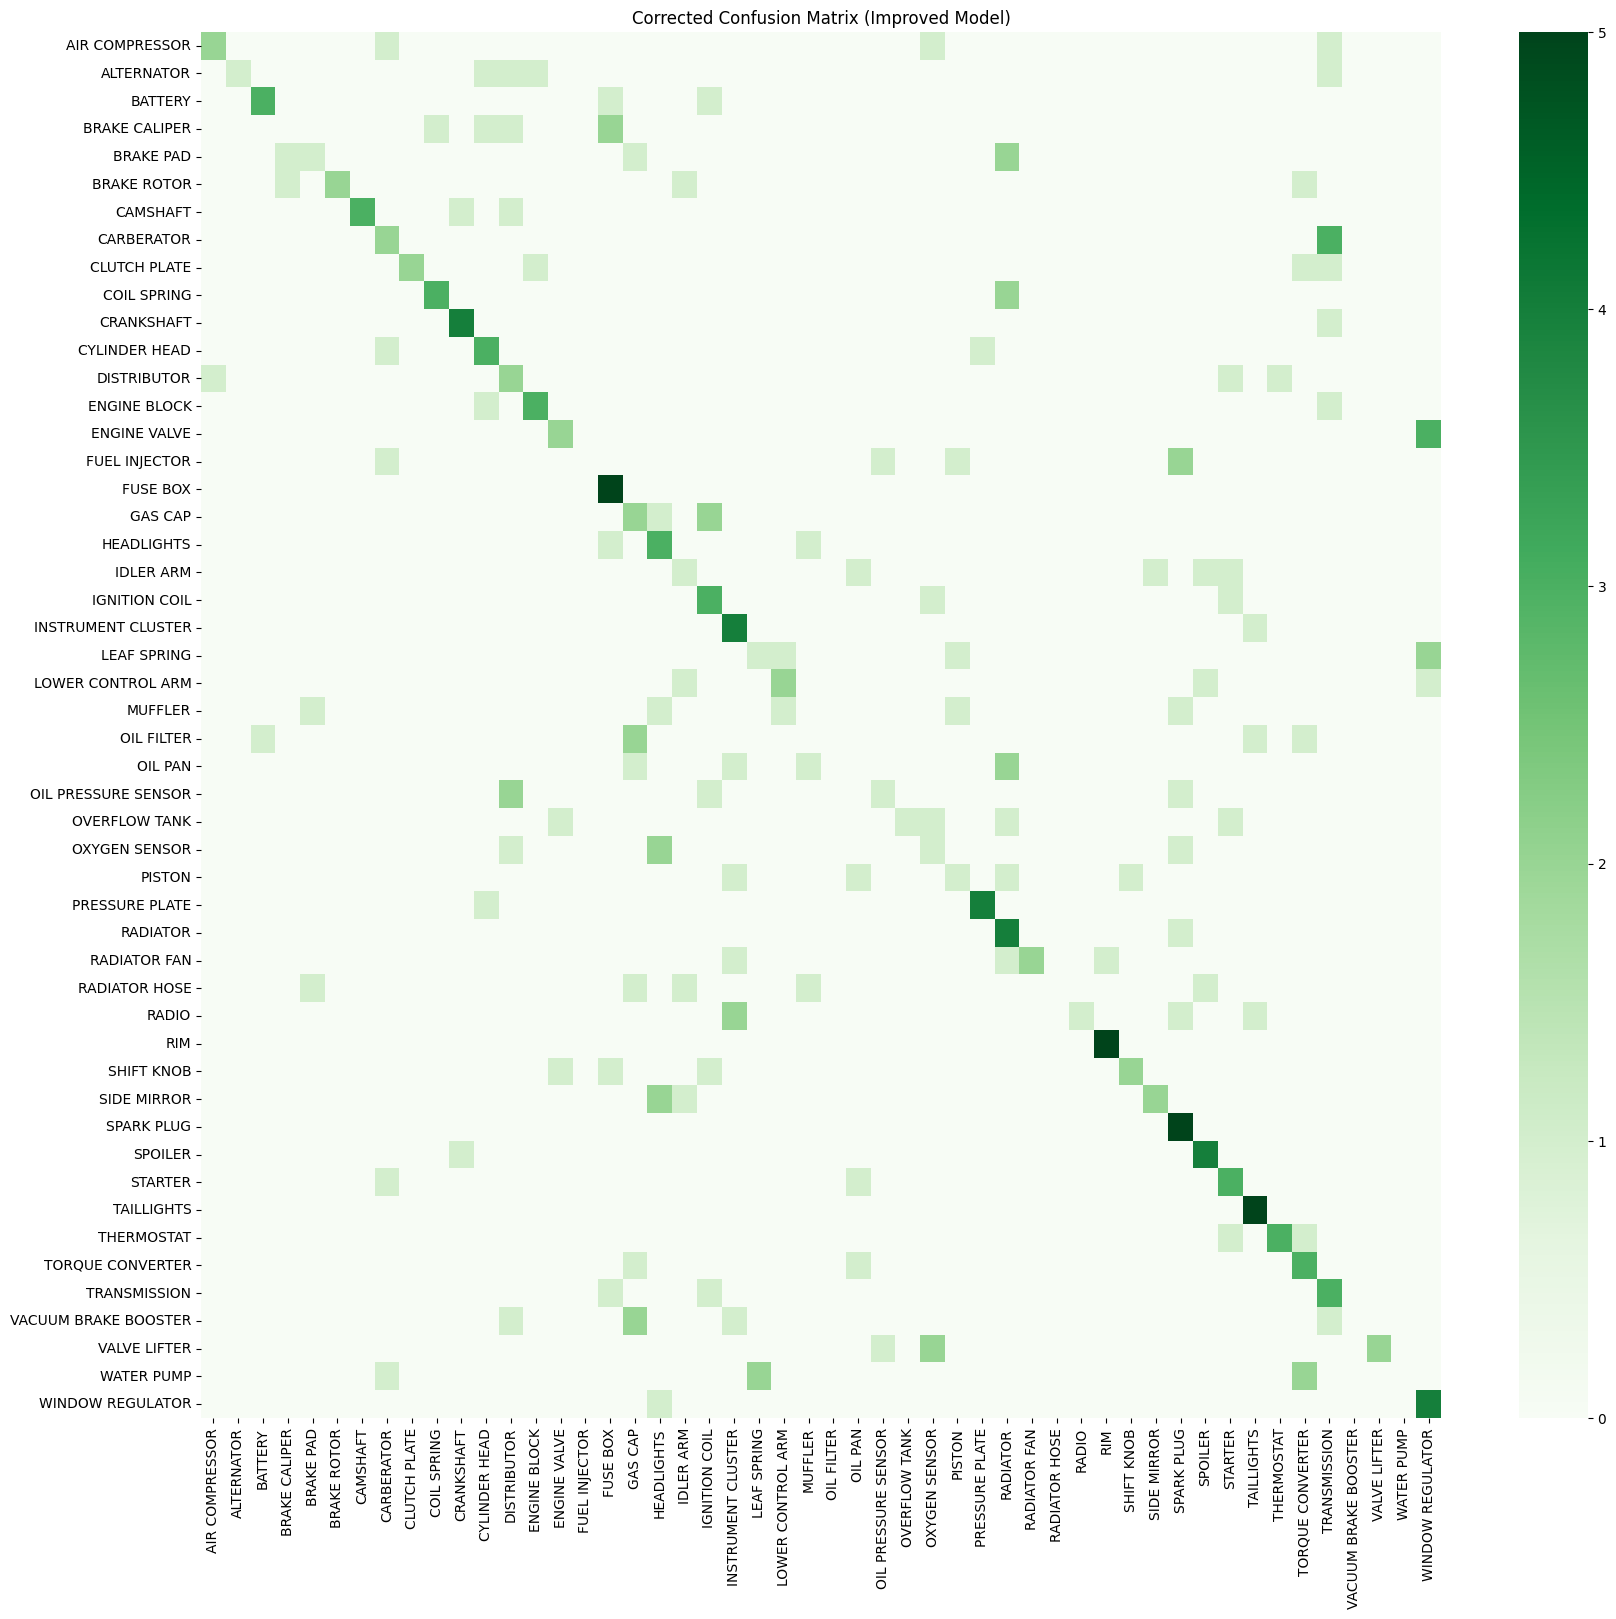

In [46]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict (Order is stable because shuffle=False)
y_pred_logits = improved_model.predict(test_ds)
y_pred_classes = np.argmax(y_pred_logits, axis=1)

# 2. Get True Labels (Iterate through the same stable order)
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds], axis=0)

# 3. Generate correct metrics
print("--- Final Results for Improved Model ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names, zero_division=0))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Corrected Confusion Matrix (Improved Model)')
plt.show()

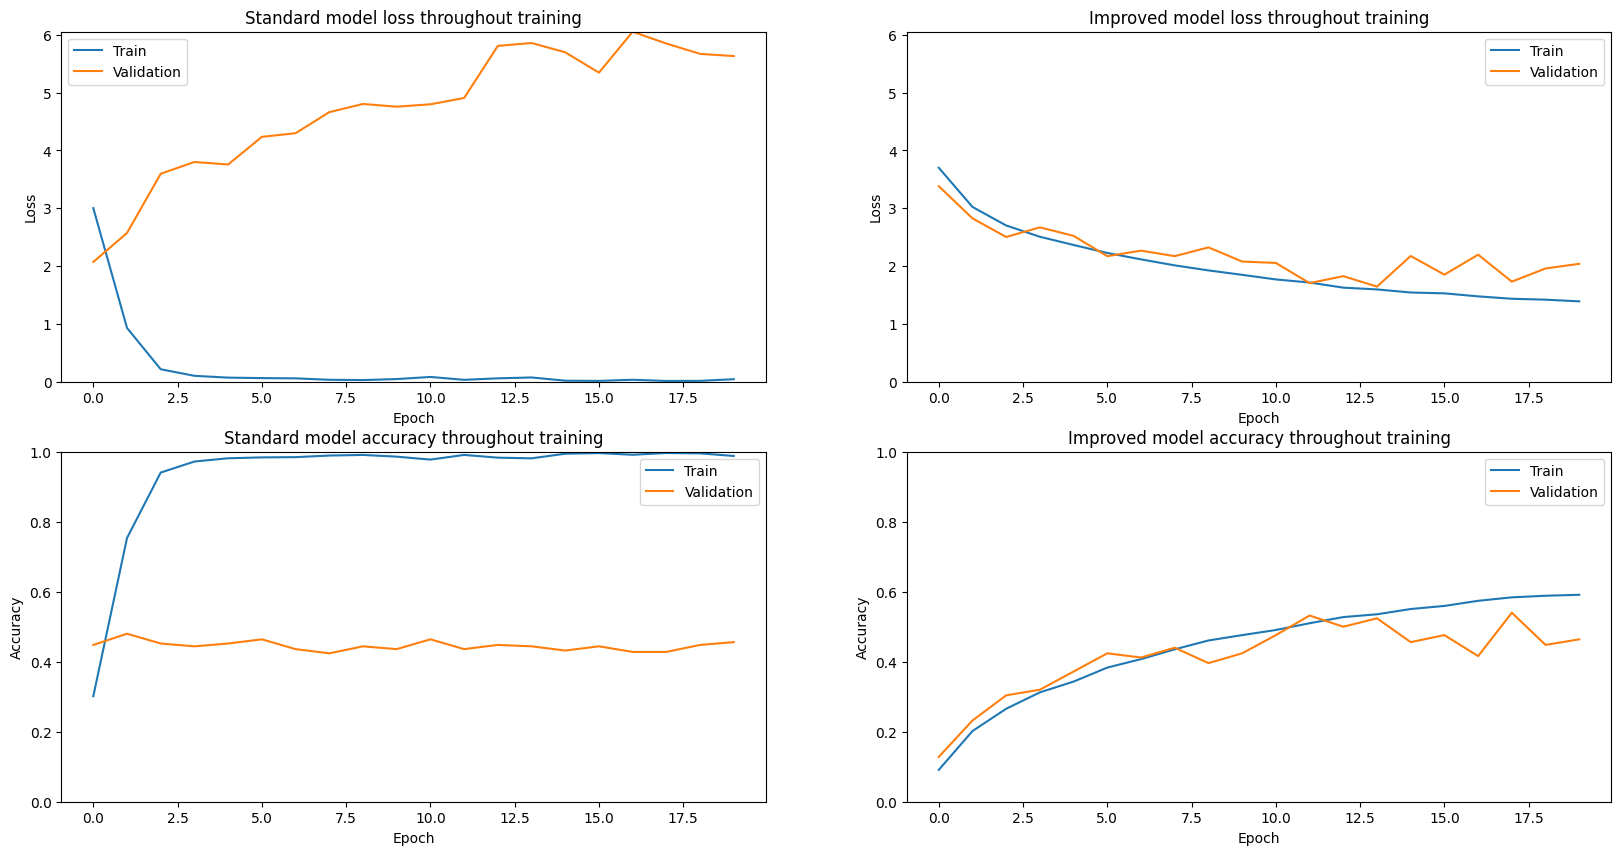

In [47]:
# take the max loss
ml1 = max(history.history['loss'])
ml2 = max(history.history['val_loss'])
ml3 = max(history_improved.history['loss'])
ml4 = max(history_improved.history['val_loss'])
max_loss = max(ml1, ml2, ml3, ml4)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

# first row, loss
axs[0][0].plot(history.history['loss'])
axs[0][0].plot(history.history['val_loss'])
axs[0][0].set_title("Standard model loss throughout training")
axs[0][0].set_ylim(0, max_loss)
axs[0][0].set_xlabel("Epoch")
axs[0][0].set_ylabel("Loss")
axs[0][0].legend(['Train', 'Validation'])

axs[0][1].plot(history_improved.history['loss'])
axs[0][1].plot(history_improved.history['val_loss'])
axs[0][1].set_title("Improved model loss throughout training")
axs[0][1].set_ylim(0, max_loss)
axs[0][1].set_xlabel("Epoch")
axs[0][1].set_ylabel("Loss")
axs[0][1].legend(['Train', 'Validation'])

# second row, accuracy
axs[1][0].plot(history.history['accuracy'], animated=True)
axs[1][0].plot(history.history['val_accuracy'])
axs[1][0].set_ylim(0, 1)
axs[1][0].set_title("Standard model accuracy throughout training")
axs[1][0].set_xlabel("Epoch")
axs[1][0].set_ylabel("Accuracy")
axs[1][0].legend(['Train', 'Validation'])

axs[1][1].plot(history_improved.history['accuracy'], animated=True)
axs[1][1].plot(history_improved.history['val_accuracy'])
axs[1][1].set_ylim(0, 1)
axs[1][1].set_title("Improved model accuracy throughout training")
axs[1][1].set_xlabel("Epoch")
axs[1][1].set_ylabel("Accuracy")
axs[1][1].legend(['Train', 'Validation'])

In conclusion, we can see that these 2 techniques helped the model behave better with accuracy/ loss curves moving in tandem between training and validation, which is how a correct model should work; this shows us that we have succesfully prevented overfitting. While the validation loss is significantly better, validation accuracy didn't improve that much, but at least it follows the training accuracy.

The testing set results are quite interesting: while both models have the same accuracy in validation, the improved model generalizes worse on the testing set! It has an accuracy of only 11% while the standard one had almost 40%! This shows that while we have eliminated overfitting, our model is underfitting now. We could fix this by making the model more complex, while paying attention to data augmentation and other tools to prevent overfitting again.

### A Note on Data Leakage and Generalization 💡

It is highly probable that the **Standard Model**'s higher score is an illusion caused by **implicit data leakage**. If the training and testing images were taken by the same camera or in the same environment, the model might be classifying based on:
- Background colors or patterns.
- Lighting conditions.
- Specific image artifacts.

To verify the **Improved Model's** true value, we should ideally test it on a completely independent dataset (e.g., images from Google Images or a different professional source). This would likely show that while the Standard Model fails completely on new data, the Improved Model retains its (albeit currently low) accuracy because it learned actual object features rather than just pixel noise.

# Part 4: transfer learning ✈️

## Chapter 1: choosing a model
I am going to choose MobileNet from Google thanks to its efficiency, which would allow for faster training in a learning project.

Transfer learning is based on choosing an Internet model that was trained on a huge, general dataset (eg: 1 milion images) and completing it with a few, custom layers that address our task rather than the specific one the model was trained on. We will freeze the pre-trained model's weights and allow the tuning of weights only on our custom layers, which will make the training faster. Then, we will unfreeze some deeper layers on the pre-trained model and adjust their weights too in order to create a better transition from the general textures onto our specific features. It's basically adapting the general knowledge to our task.

Such applications are especially useful on small datasets like ours, where we don't have enough images.

In [3]:
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False,input_shape=(224,224,3))

base_model.trainable = False

## Chapter 2: adding our custom layers

In [5]:
tl_model = tf.keras.Sequential([base_model, tf.keras.layers.GlobalAveragePooling2D(), tf.keras.layers.Dropout(0.3), tf.keras.layers.Dense(50, activation='softmax')])

tl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        64,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,322,034 (8.86 MB)

 Trainable params: 64,050 (250.20 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Chapter 3: compile and train the model

In [18]:
tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # used because we are dealing with categorical data
    metrics=['accuracy'])

tl_history = tl_model.fit(train_ds, validation_data=valid_ds, epochs=20)

Epoch 1/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 923s 3s/step - accuracy: 0.8474 - loss: 0.5124 - val_accuracy: 0.8680 - val_loss: 0.4909
Epoch 2/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9159 - loss: 0.2813 - val_accuracy: 0.8640 - val_loss: 0.4549
Epoch 3/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.9435 - loss: 0.2006 - val_accuracy: 0.8800 - val_loss: 0.4431
Epoch 4/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9585 - loss: 0.1560 - val_accuracy: 0.8880 - val_loss: 0.4234
Epoch 5/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.9667 - loss: 0.1245 - val_accuracy: 0.8840 - val_loss: 0.4275
Epoch 6/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.9726 - loss: 0.1041 - val_accuracy: 0.8920 - val_loss: 0.4140
Epoch 7/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9797 - loss: 0.0870 - val_accuracy: 0.9000 - val_loss: 0.4514
Epoch 8/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.9789 - loss: 0.0811 - v

## Chapter 4: test the model and see how it compares to the previous ones

In [20]:
# generate predictions
y_pred_logits_tl = tl_model.predict(test_ds)
y_pred_classes_tl = np.argmax(y_pred_logits_tl, axis=1)

# get true labels
y_true_tl = []
for images, labels in test_ds:
    y_true_tl.extend(np.argmax(labels.numpy(), axis=1))
y_true_tl = np.array(y_true_tl)

8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step


--- Transfer Learning Model: Classification Report ---
                      precision    recall  f1-score   support

      AIR COMPRESSOR       1.00      1.00      1.00         5
          ALTERNATOR       1.00      1.00      1.00         5
             BATTERY       0.83      1.00      0.91         5
       BRAKE CALIPER       1.00      0.80      0.89         5
           BRAKE PAD       1.00      1.00      1.00         5
         BRAKE ROTOR       1.00      1.00      1.00         5
            CAMSHAFT       1.00      0.80      0.89         5
          CARBERATOR       1.00      1.00      1.00         5
        CLUTCH PLATE       1.00      1.00      1.00         5
         COIL SPRING       1.00      1.00      1.00         5
          CRANKSHAFT       0.83      1.00      0.91         5
       CYLINDER HEAD       1.00      0.80      0.89         5
         DISTRIBUTOR       0.83      1.00      0.91         5
        ENGINE BLOCK       0.83      1.00      0.91         5
        ENGINE

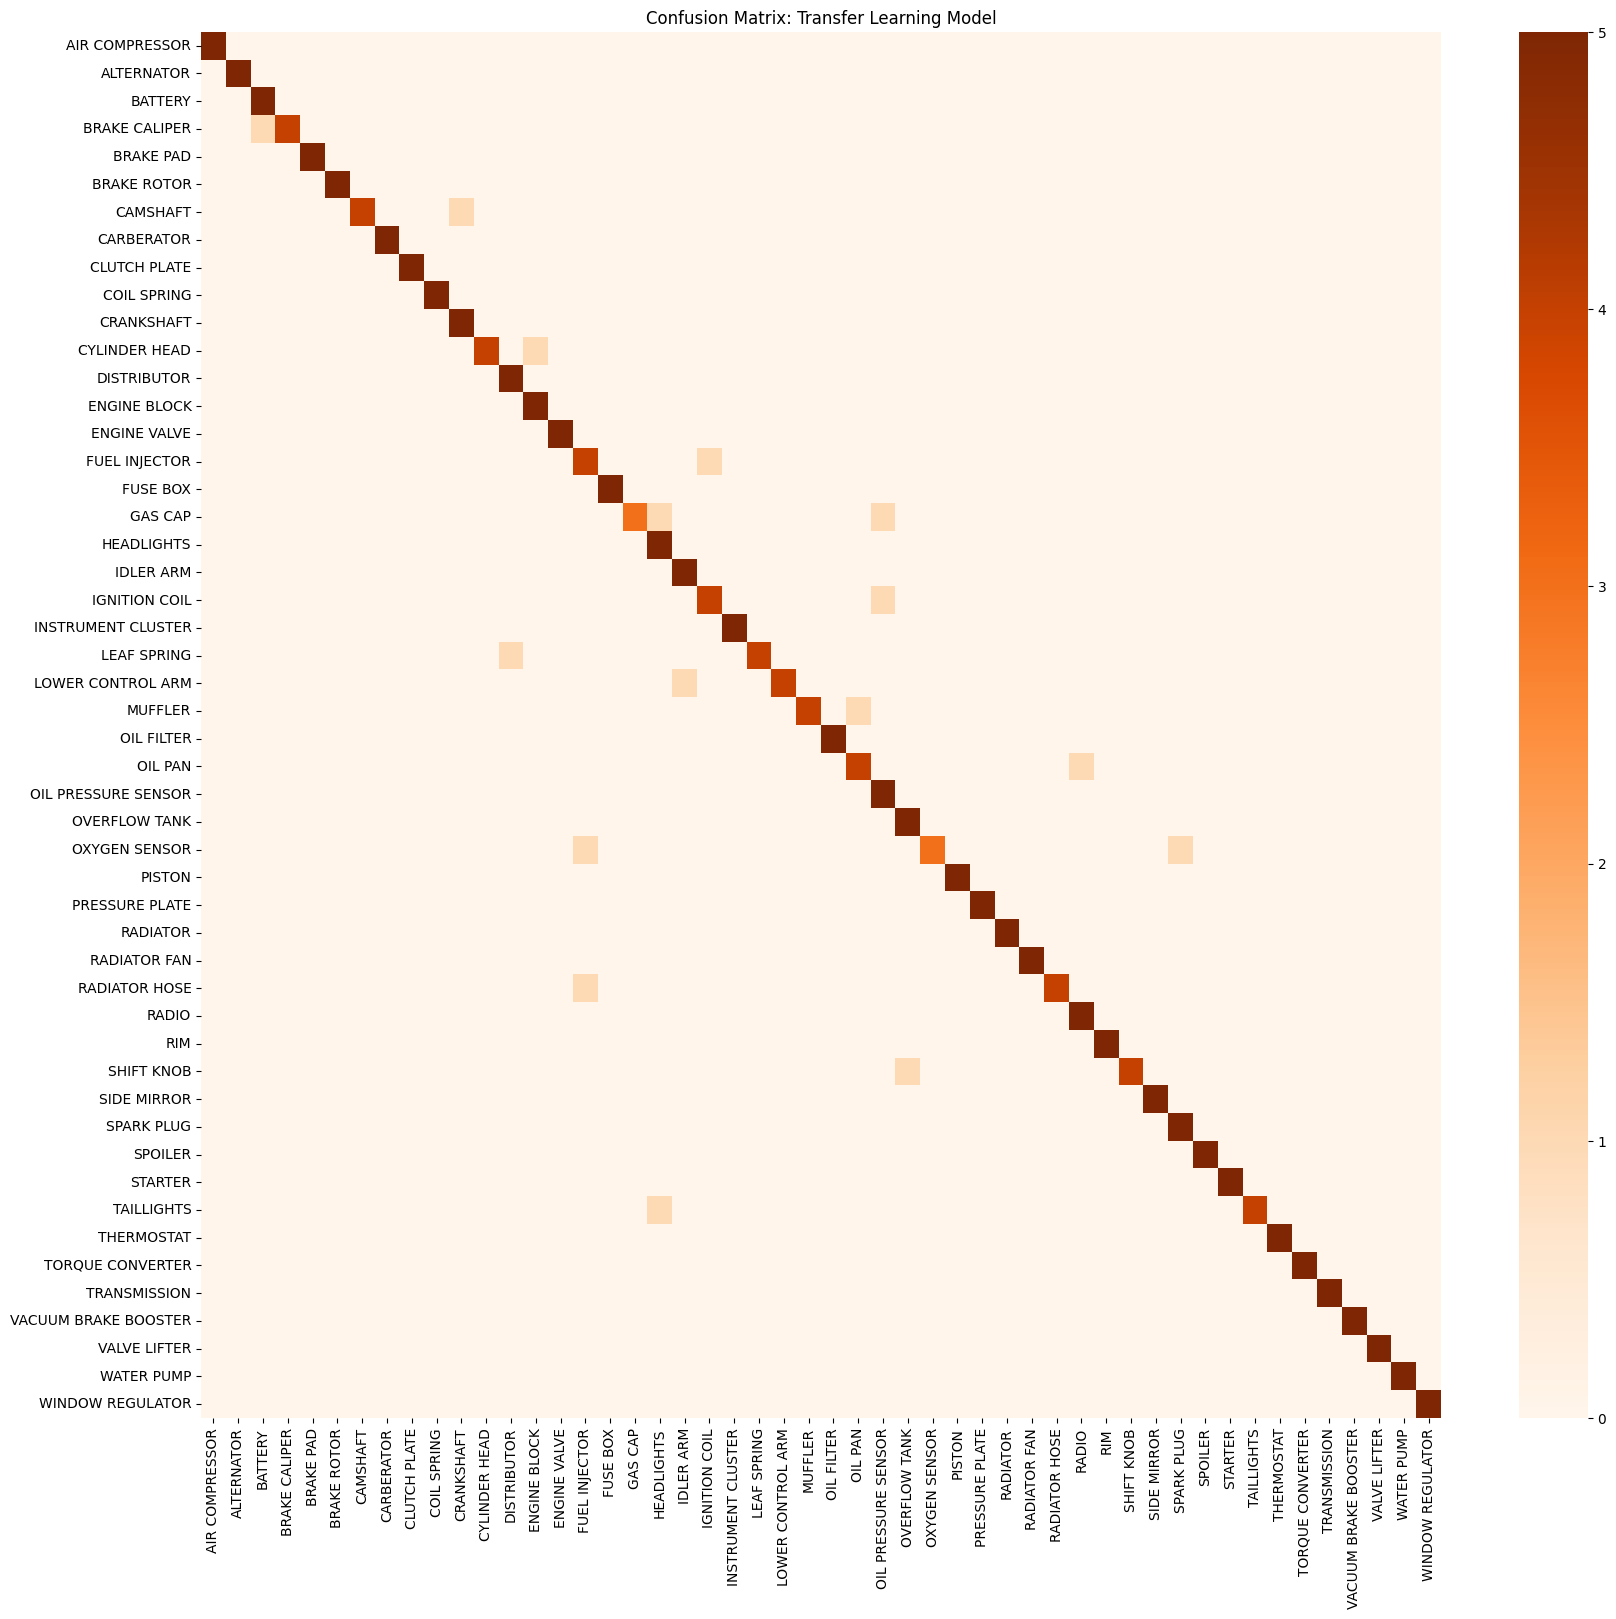

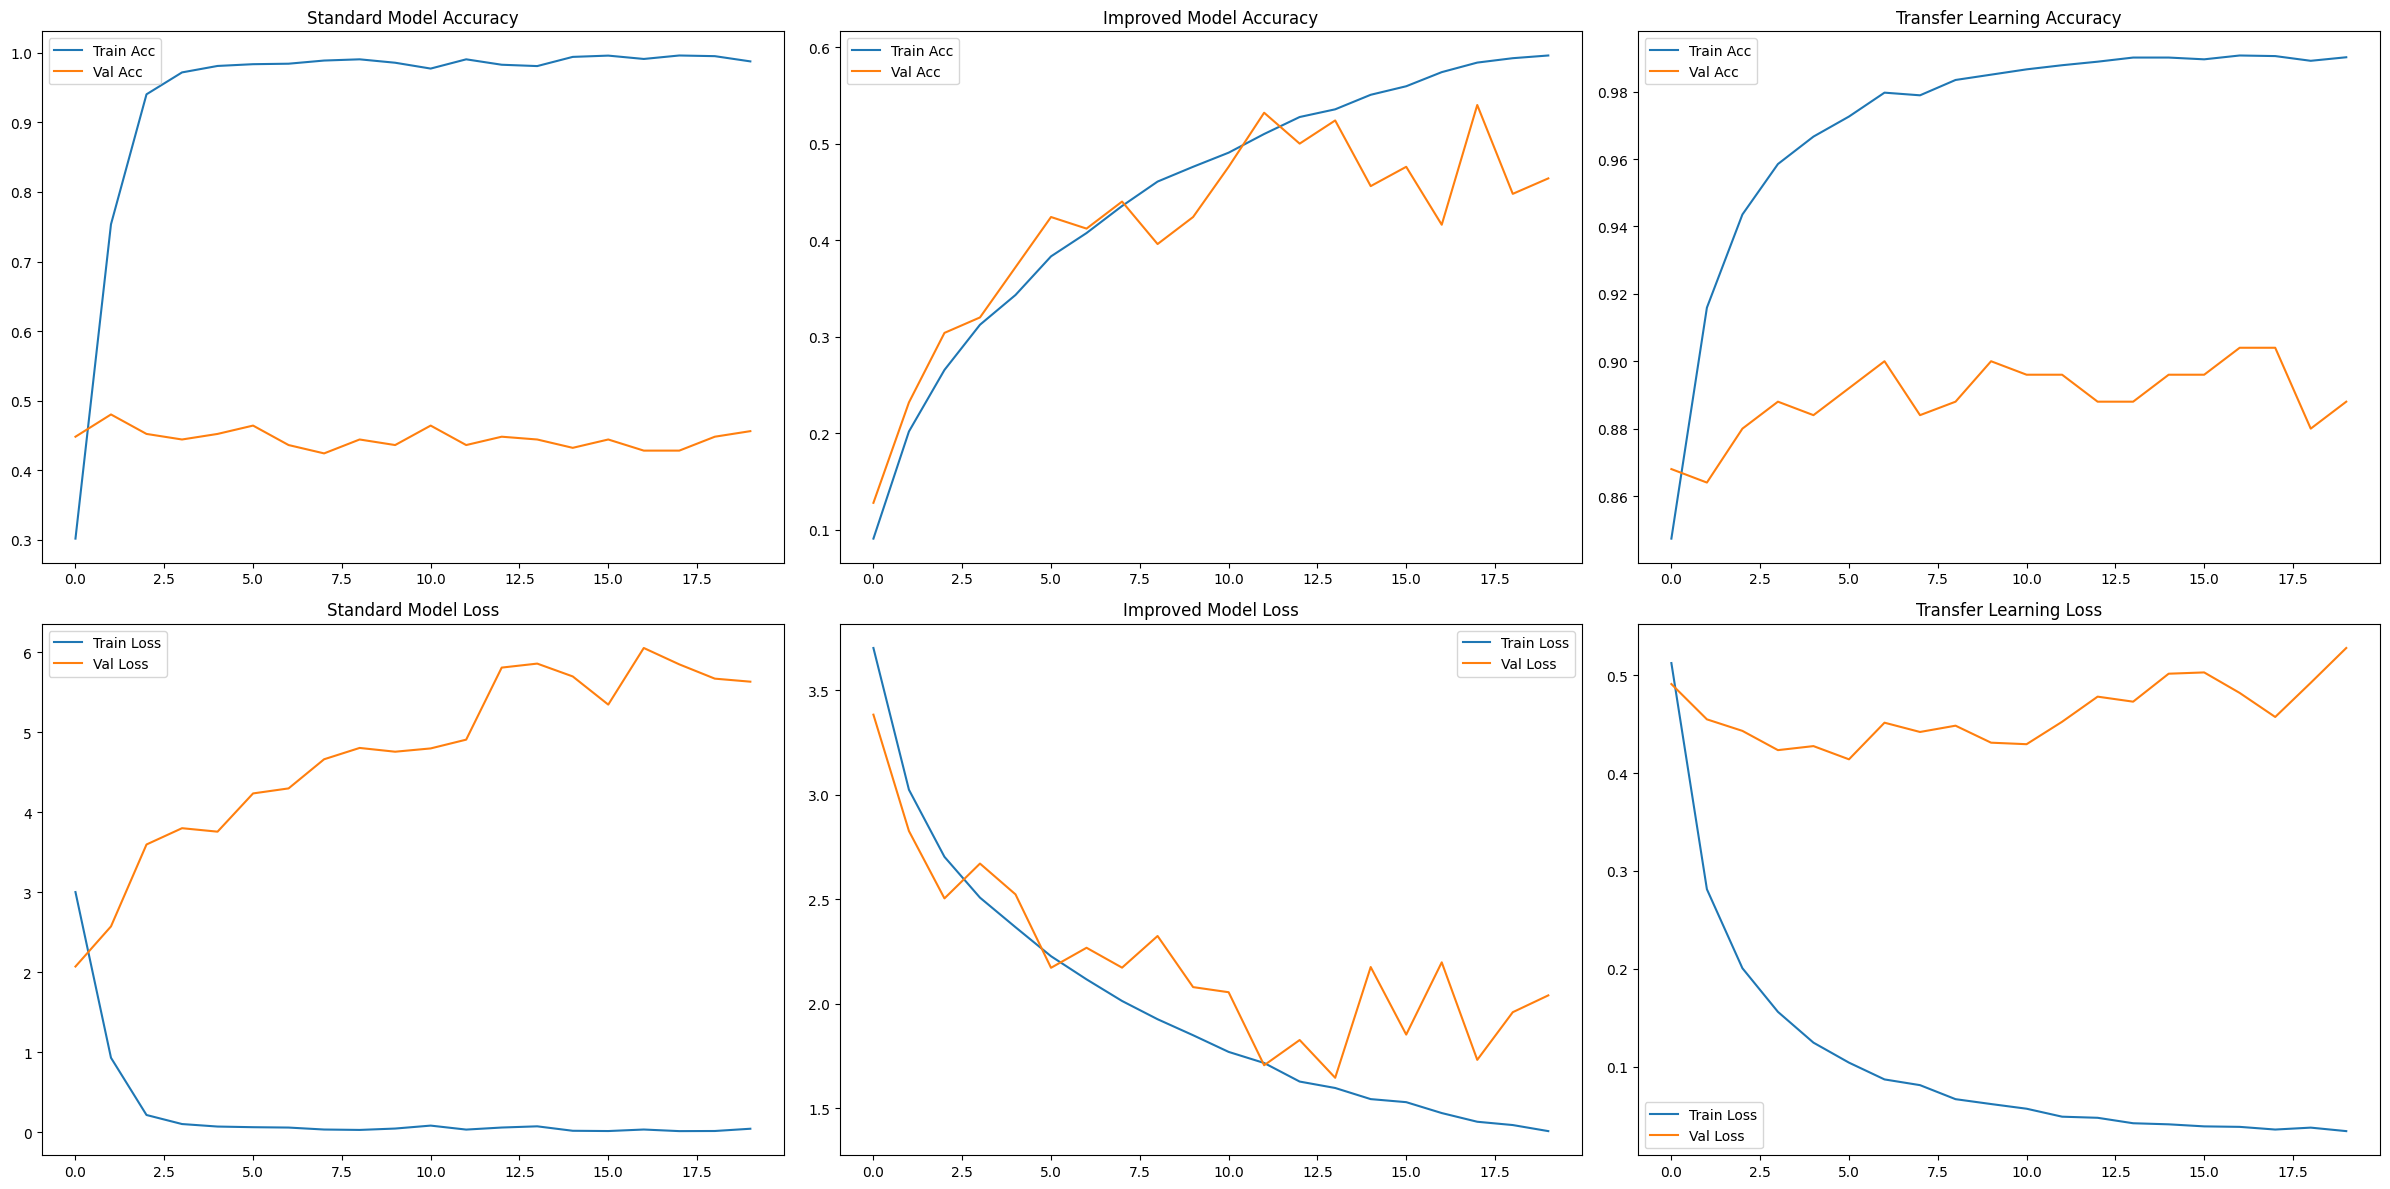

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Classification Report for Transfer Learning Model
print("--- Transfer Learning Model: Classification Report ---")
print(classification_report(y_true_tl, y_pred_classes_tl, target_names=class_names, zero_division=0))

# 2. Confusion Matrix for Transfer Learning Model
plt.figure(figsize=(20, 18))
cm_tl = confusion_matrix(y_true_tl, y_pred_classes_tl)
sns.heatmap(cm_tl, annot=False, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Transfer Learning Model')
plt.show()

# 3. Comparative Plots (2 rows, 3 columns)
fig, axs = plt.subplots(2, 3, figsize=(24, 12))

# Standard Model Plots
axs[0, 0].plot(history.history['accuracy'], label='Train Acc')
axs[0, 0].plot(history.history['val_accuracy'], label='Val Acc')
axs[0, 0].set_ylim(0, 1)
axs[0, 0].set_title("Standard Model Accuracy")
axs[0, 0].legend()

axs[1, 0].plot(history.history['loss'], label='Train Loss')
axs[1, 0].plot(history.history['val_loss'], label='Val Loss')
axs[1, 0].set_title("Standard Model Loss")
axs[1, 0].legend()

# Improved Model Plots
axs[0, 1].plot(history_improved.history['accuracy'], label='Train Acc')
axs[0, 1].plot(history_improved.history['val_accuracy'], label='Val Acc')
axs[0, 1].set_title("Improved Model Accuracy")
axs[0, 1].set_ylim(0, 1)
axs[0, 1].legend()

axs[1, 1].plot(history_improved.history['loss'], label='Train Loss')
axs[1, 1].plot(history_improved.history['val_loss'], label='Val Loss')
axs[1, 1].set_title("Improved Model Loss")
axs[1, 1].legend()

# Transfer Learning Model Plots
axs[0, 2].plot(tl_history.history['accuracy'], label='Train Acc')
axs[0, 2].plot(tl_history.history['val_accuracy'], label='Val Acc')
axs[0, 2].set_title("Transfer Learning Accuracy")
axs[0, 2].set_ylim(0, 1)
axs[0, 2].legend()

axs[1, 2].plot(tl_history.history['loss'], label='Train Loss')
axs[1, 2].plot(tl_history.history['val_loss'], label='Val Loss')
axs[1, 2].set_title("Transfer Learning Loss")
axs[1, 2].legend()

plt.tight_layout()
plt.show()

Unsurprisingly, the model that was trained on a bigger dataset and that was developed by Google generalizes well. We have applied the principles of transfer learning to suit that general model onto our specific task, which turned out to work pretty well, oferring us a 94% accuracy. Keep in mind that this is lightweight model intended for embeded / mobile devices!

Looking at the heatmap we see very clearly the diagonal line, with only a few errors. No class was mislabeled twice with the same wrong class.

The curves tell the same story: the transfer learning model is the best one, having the best accuracy. However, the nicest correlation between the training and validation is still at the improved model. The transfer learning shows some small signs of overfitting, but its performance is still good.